In [ ]:
import pandas as pd

df = pd.read_csv('/content/ipums_sample_10pct.csv')

# Menampilkan 5 baris pertama
df.head(50)

,COUNTRY,YEAR,SAMPLE,SERIAL,HHWT,PERNUM,PERWT,AGE,SEX,EDATTAIN,EDATTAIND,EMPSTAT,EMPSTATD,OCCISCO,INDGEN,INCTOT,INCEARN
0,76,2010,76201001,3000,9.50,5.0,9.50,17.0,2.0,2.0,212.0,3.0,300.0,99.0,0.0,0.0,99999999.0
1,76,2010,76201001,5000,12.00,1.0,12.00,57.0,2.0,1.0,110.0,3.0,300.0,99.0,0.0,510.0,99999999.0
2,76,2010,76201001,5000,12.00,3.0,12.00,42.0,1.0,2.0,221.0,1.0,110.0,7.0,50.0,2000.0,2000.0
3,76,2010,76201001,16000,12.03,3.0,12.03,55.0,2.0,3.0,311.0,1.0,110.0,1.0,112.0,3600.0,1800.0
4,76,2010,76201001,19000,9.79,4.0,9.79,39.0,2.0,4.0,400.0,1.0,110.0,11.0,100.0,1200.0,1200.0
5,76,2010,76201001,21000,7.57,1.0,7.57,27.0,1.0,1.0,120.0,3.0,300.0,99.0,0.0,0.0,99999999.0
6,76,2010,76201001,22000,8.50,3.0,8.50,22.0,1.0,2.0,212.0,1.0,110.0,6.0,10.0,300.0,300.0
7,76,2010,76201001,23000,11.48,1.0,11.48,37.0,1.0,1.0,120.0,1.0,120.0,9.0,40.0,510.0,510.0
8,76,2010,76201001,25000,8.81,2.0,8.81,55.0,2.0,1.0,110.0,3.0,300.0,99.0,0.0,0.0,99999999.0
9,76,2010,76201001,28000,8.80,1.0,8.80,37.0,1.0,1.0,120.0,3.0,300.0,99.0,0.0,0.0,99999999.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import time
import psutil
import os

from IPython.display import display

plt.style.use("ggplot")

In [ ]:
# Load Dataset dan Benchmark Waktu Baca
start_time = time.time()

df = pd.read_csv('/content/ipums_sample_10pct.csv')

read_time = time.time() - start_time

print(f"Waktu membaca CSV: {read_time:.2f} detik")
print(f"Ukuran data: {df.shape}")

Waktu membaca CSV: 0.27 detik
Ukuran data: (155420, 17)


In [ ]:
# Informasi Dataset
df.info()

print("\nJumlah Missing Value:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155420 entries, 0 to 155419
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   COUNTRY    155420 non-null  int64  
 1   YEAR       155420 non-null  int64  
 2   SAMPLE     155420 non-null  int64  
 3   SERIAL     155420 non-null  int64  
 4   HHWT       155420 non-null  float64
 5   PERNUM     155420 non-null  int64  
 6   PERWT      155420 non-null  float64
 7   AGE        155420 non-null  int64  
 8   SEX        155420 non-null  int64  
 9   EDATTAIN   155420 non-null  int64  
 10  EDATTAIND  155420 non-null  int64  
 11  EMPSTAT    155420 non-null  int64  
 12  EMPSTATD   155420 non-null  int64  
 13  OCCISCO    155420 non-null  int64  
 14  INDGEN     155420 non-null  int64  
 15  INCTOT     155420 non-null  float64
 16  INCEARN    155420 non-null  int64  
dtypes: float64(3), int64(14)
memory usage: 20.2 MB

Jumlah Missing Value:
COUNTRY      0
YEAR         0
SAMPL

In [ ]:
# Data Cleaning
df_clean = df.copy()

df_clean = df_clean[
    (df_clean["INCTOT"] > 0)
]

df_clean = df_clean[
    (df_clean["INCTOT"] < 9999999)
]

print("Jumlah data setelah cleaning:")
print(df_clean.shape)

Jumlah data setelah cleaning:
(70750, 17)


In [ ]:
# Statistik Deskriptif Income
df_clean["INCTOT"].describe()

,INCTOT
count,70750.000000
mean,942.746869
std,3147.114109
min,1.000000
25%,300.000000
50%,510.000000
75%,900.000000
max,510000.000000


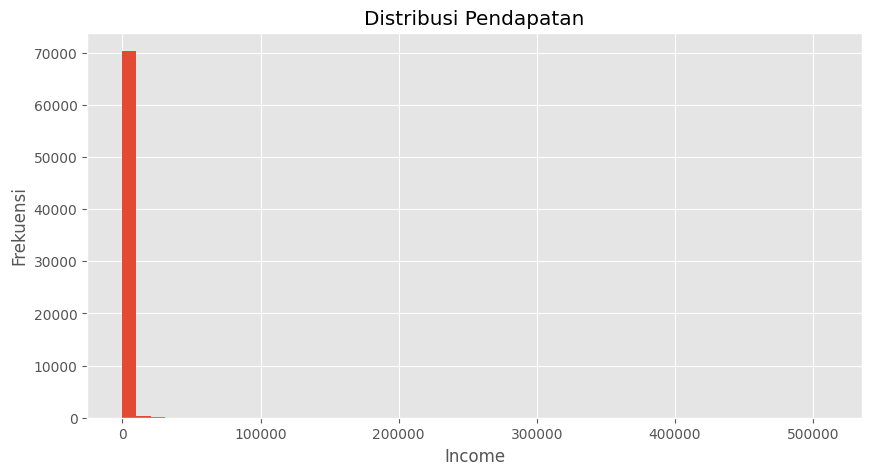

In [ ]:
# Distribusi Pendapatan
plt.figure(figsize=(10,5))

plt.hist(
    df_clean["INCTOT"],
    bins=50
)

plt.xlabel("Income")
plt.ylabel("Frekuensi")
plt.title("Distribusi Pendapatan")

plt.show()

In [ ]:
# Memory Usage
memory_mb = (
    df_clean.memory_usage(deep=True).sum()
    /1024**2
)

print(f"Memory Usage: {memory_mb:.2f} MB")

Memory Usage: 9.72 MB


In [ ]:
# Fungsi Gini Exact
def gini(x):

    x = np.array(x)

    x = x[x >= 0]

    x = np.sort(x)

    n = len(x)

    index = np.arange(1, n+1)

    return (
        np.sum((2*index - n - 1)*x)
        /
        (n*np.sum(x))
    )

In [ ]:
# Hitung Gini
start_time = time.time()

gini_value = gini(
    df_clean["INCTOT"]
)

gini_time = time.time() - start_time

print(f"Gini Coefficient = {gini_value:.4f}")
print(f"Waktu eksekusi = {gini_time:.4f} detik")

Gini Coefficient = 0.5678
Waktu eksekusi = 0.0035 detik


In [ ]:
# Weighted Gini (Menggunakan PERWT)
def weighted_gini(x, w):

    x = np.asarray(x)
    w = np.asarray(w)

    sorted_idx = np.argsort(x)

    x = x[sorted_idx]
    w = w[sorted_idx]

    cumw = np.cumsum(w)

    cumxw = np.cumsum(x*w)

    return (
        np.sum(
            w * (
                cumxw - x*w/2
            )
        )
        /
        (
            cumxw[-1] * cumw[-1]
        )
        * 2 - 1
    )

In [ ]:
# Hitung Weighted Gini
start_time = time.time()

weighted_gini_value = weighted_gini(
    df_clean["INCTOT"],
    df_clean["PERWT"]
)

elapsed = time.time() - start_time

print(f"Weighted Gini = {weighted_gini_value:.4f}")
print(f"Waktu = {elapsed:.4f} detik")

Weighted Gini = -0.5831
Waktu = 0.0129 detik


In [ ]:
# Kuintil Pendapatan
df_clean["QUINTILE"] = pd.qcut(
    df_clean["INCTOT"],
    q=5,
    labels=[
        "Q1",
        "Q2",
        "Q3",
        "Q4",
        "Q5"
    ]
)

df_clean["QUINTILE"].value_counts()

,count
QUINTILE,
Q2,26152
Q1,14390
Q5,13049
Q4,12946
Q3,4213


In [ ]:
# Ringkasan
quintile_summary = (
    df_clean
    .groupby("QUINTILE")
    ["INCTOT"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max"
    ])
)

display(quintile_summary)

/tmp/ipykernel_814/2039528728.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("QUINTILE")


,count,mean,median,min,max
QUINTILE,,,,,
Q1,14390,116.085893,112.0,1.0,200.0
Q2,26152,451.633565,510.0,201.0,510.0
Q3,4213,580.713031,600.0,511.0,600.0
Q4,12946,836.909084,800.0,602.0,1020.0
Q5,13049,3060.508468,2000.0,1021.0,510000.0


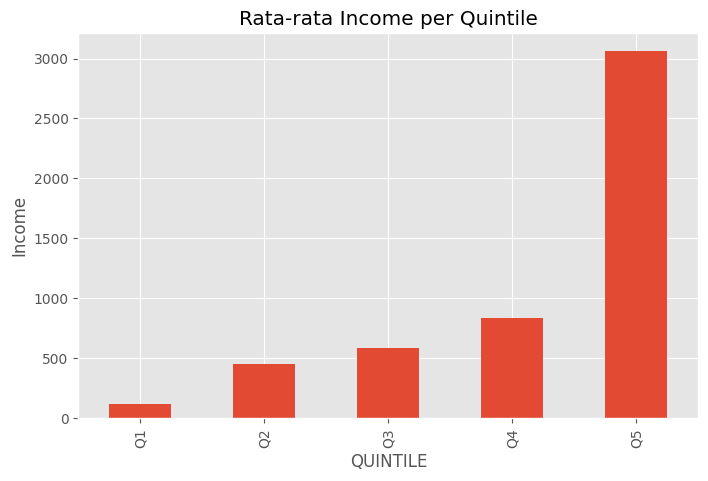

In [ ]:
# Income per Quintile
quintile_summary["mean"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Rata-rata Income per Quintile"
)

plt.ylabel("Income")
plt.show()

In [ ]:
# Benchmark Table
benchmark = pd.DataFrame({
    "Metric":[
        "Jumlah Data",
        "Memory (MB)",
        "Read CSV Time",
        "Gini Time",
        "Weighted Gini"
    ],
    "Value":[
        len(df_clean),
        memory_mb,
        read_time,
        gini_time,
        weighted_gini_value
    ]
})

benchmark

,Metric,Value
0,Jumlah Data,70750.000000
1,Memory (MB),9.716034
2,Read CSV Time,0.266165
3,Gini Time,0.003531
4,Weighted Gini,-0.583053


In [ ]:
# Simpan Hasil Benchmark
benchmark.to_csv(
    "benchmark_pandas.csv",
    index=False
)

quintile_summary.to_csv(
    "quintile_summary.csv"
)

In [ ]:
# Benchmark Throughput
rows = len(df_clean)

throughput = rows / read_time

print(f"Throughput : {throughput:,.0f} rows/sec")

Throughput : 265,812 rows/sec


In [ ]:
# Null Percentage per Kolom
null_pct = (
    df.isnull().sum()
    / len(df)
    * 100
).round(2)

null_pct.sort_values(
    ascending=False
)

,0
COUNTRY,0.0
YEAR,0.0
SAMPLE,0.0
SERIAL,0.0
HHWT,0.0
PERNUM,0.0
PERWT,0.0
AGE,0.0
SEX,0.0
EDATTAIN,0.0


In [ ]:
# Outlier Detection
Q1 = df_clean["INCTOT"].quantile(0.25)
Q3 = df_clean["INCTOT"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df_clean[
    (df_clean["INCTOT"] < lower) |
    (df_clean["INCTOT"] > upper)
]

print("Jumlah Outlier:", len(outliers))

Jumlah Outlier: 6912


In [ ]:
# Benchmark CPU Usage
import psutil

cpu = psutil.cpu_percent(interval=1)

print(cpu)

55.7


In [ ]:
# Benchmark Memory Peak
import tracemalloc

tracemalloc.start()

# proses gini

current, peak = tracemalloc.get_traced_memory()

print(
    f"Peak Memory: {peak/1024/1024:.2f} MB"
)

tracemalloc.stop()

Peak Memory: 0.02 MB
